# Airbnb Seattle Pricing Analysis 
This notebook answers the following question:

**How does listing price vary across neighborhoods and property characteristics such as size and room type?**

The analysis is purely descriptive. It focuses on summary statistics and visual comparisons.

The analysis uses a cleaned dataset prepared in a separate data cleaning notebook. Prices are converted to numeric values, missing prices are backfilled where possible, extreme outliers are trimmed, and the sample is filtered to comparable short term listings.

## Import Packages and Load Data

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option('display.max_columns', None)

listings = pd.read_csv('data/listings_cleaned.csv')

analysis_df = listings.dropna(
    subset=[
        "price",
        "neighbourhood_group_cleansed",
        "neighbourhood_cleansed",
        "room_type",
        "accommodates",
    ]
)

analysis_df.head()

,id,neighbourhood_group_cleansed,neighbourhood_cleansed,price,accommodates,bedrooms,beds,bathrooms,room_type,minimum_nights,number_of_reviews,review_scores_rating,price_backfilled
0,9419,Other neighborhoods,Georgetown,71.0,2,1.0,2.0,3.0,Private room,2,220,4.73,False
1,25002,Ballard,Whittier Heights,88.0,4,1.0,2.0,1.0,Entire home/apt,2,1139,4.93,False
2,119103,Other neighborhoods,Fremont,92.0,3,2.0,2.0,1.0,Entire home/apt,3,597,4.94,False
3,215882,Rainier Valley,Columbia City,111.0,2,1.0,1.0,1.0,Entire home/apt,2,419,4.89,False
4,226536,Magnolia,Lawton Park,74.0,2,1.0,1.0,1.0,Private room,1,417,4.83,False


In [26]:
# Price formatter for charts.
price_formatter = FuncFormatter(lambda x, _: f"${x:,.0f}")

## 1.1 Neighborhood Pricing

This section compares listing prices across neighborhood groups using average and median listed prices, and examines whether observed differences are driven in part by listing composition, such as room type and size.

We analyze pricing at the neighborhood group level rather than individual neighborhoods, as the dataset contains 87 distinct neighborhoods. Aggregating to broader groups improves interpretability and avoids small sample sizes. These groups are pre-defined in the Inside Airbnb data and make the neighborhood comparisons easier to interpret.

While average prices differ across neighborhoods, substantial within-group variation suggests that listing characteristics, in addition to location, play an important role.

In [27]:
unique_neighborhoods = len(analysis_df['neighbourhood_cleansed'].unique())
print(f'There are {unique_neighborhoods} unique neighborhoods.')

There are 87 unique neighborhoods.


### Summary statistics by neighborhood group
Note on neighborhood filtering: To improve interpretability, we exclude the "Other neighborhoods" category when comparing prices across neighborhood groups. This category represents a heterogenous mix of listings across multiple areas, making it difficult to interpret as a single neighborhood group.

In [28]:
other = analysis_df[
    analysis_df['neighbourhood_group_cleansed'] == 'Other neighborhoods'
]['price']

other.agg(['min', 'max', 'mean', 'std']).round(2)

min       40.00
max     1536.00
mean     183.86
std      132.01
Name: price, dtype: float64

In [29]:
filtered_df = analysis_df[
    analysis_df['neighbourhood_group_cleansed'] != 'Other neighborhoods'
].copy()

filtered_df.shape

(3554, 13)

In [30]:
# Calculate summary statistics by neighborhood group.
neighborhood_summary = (
    filtered_df.groupby("neighbourhood_group_cleansed")["price"]
    .agg(
        average_price="mean", 
        median_price="median", 
        standard_deviation='std', 
        listing_count="count"
    )
    .sort_values("average_price", ascending=False)
    .round(2)
)

neighborhood_summary

,average_price,median_price,standard_deviation,listing_count
neighbourhood_group_cleansed,,,,
Queen Anne,244.84,196.0,190.07,400
Cascade,224.17,204.0,124.34,75
Downtown,205.47,174.0,140.59,575
Interbay,197.92,184.0,118.64,13
Central Area,195.51,170.0,110.76,419
Magnolia,193.49,145.5,160.29,70
Capitol Hill,189.66,162.0,102.85,344
Ballard,181.40,151.0,100.55,313
West Seattle,176.00,155.0,95.93,370


### Average and median listed price by neighborhood group

In [31]:
# Sort top 5 neighborhood groups for plotting
avg_sorted = (
    neighborhood_summary["average_price"]
    .sort_values(ascending=False)
    .head(5)
    .sort_values(ascending=True)
)

median_sorted = (
    neighborhood_summary["median_price"]
    .sort_values(ascending=False)
    .head(5)
    .sort_values(ascending=True)
)

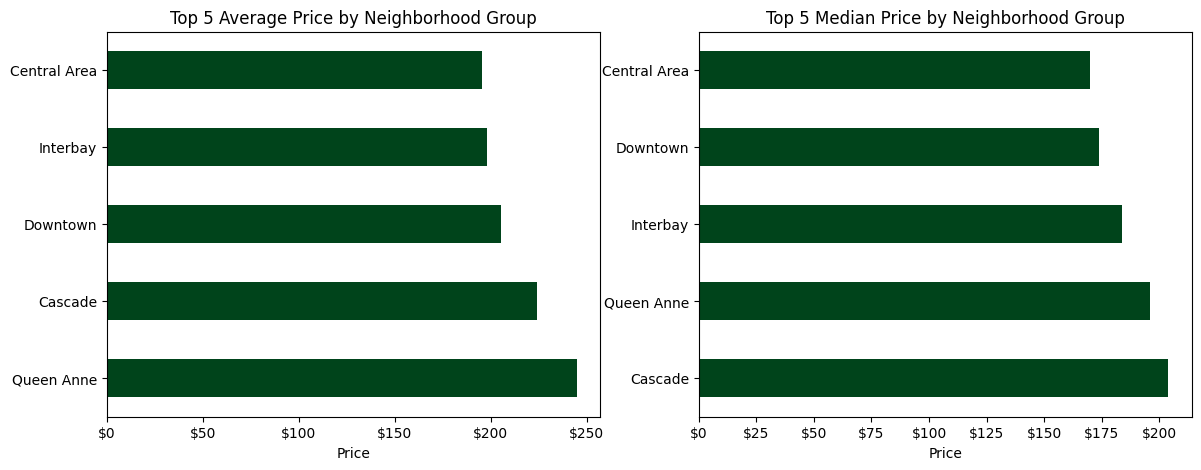

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average price
avg_sorted.plot(kind="barh", colormap="Greens_r", ax=axes[0])
axes[0].set_title("Top 5 Average Price by Neighborhood Group")
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(price_formatter)
axes[0].set_xlabel("Price")
axes[0].set_ylabel("")
axes[0].grid(False)

# Median price
median_sorted.plot(kind="barh", colormap="Greens_r", ax=axes[1])
axes[1].set_title("Top 5 Median Price by Neighborhood Group")
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(price_formatter)
axes[1].set_xlabel("Price")
axes[1].set_ylabel("")
axes[1].grid(False)

plt.show()

Comparing averages and medians is useful because averages are more sensitive to unusually expensive listings. Neighborhoods that rank highly on both measures are more likely to reflect broadly higher prices rather than a small number of outliers.

### Price distributions by neighborhood group

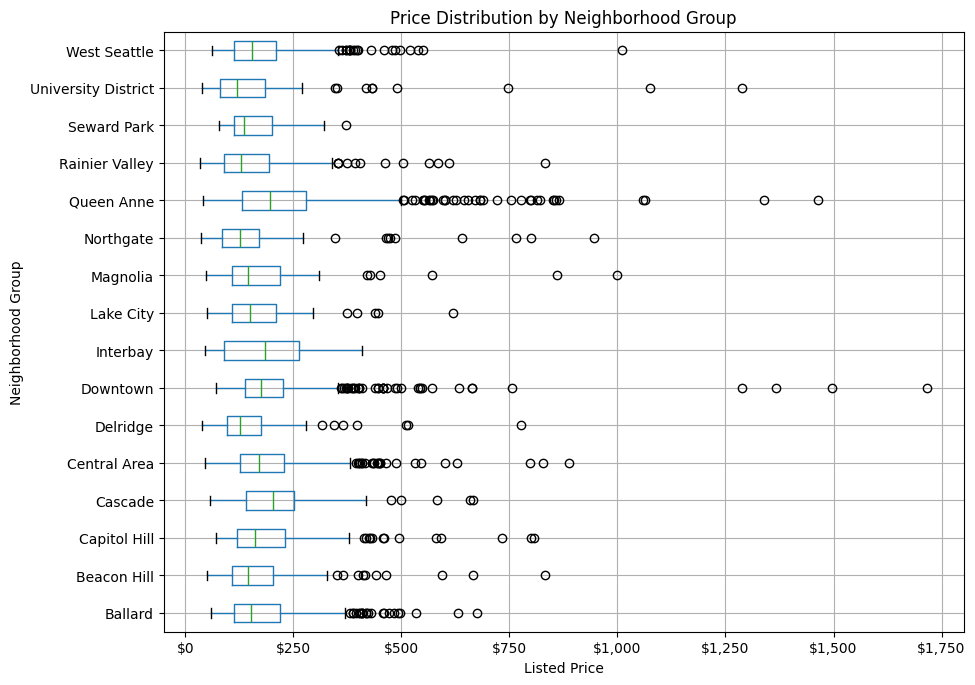

In [33]:
fig, ax = plt.subplots(figsize=(10, 8))
filtered_df.boxplot(
    column="price",
    by="neighbourhood_group_cleansed",
    vert=False,
    ax=ax
)
ax.set_title("Price Distribution by Neighborhood Group")
ax.set_xlabel("Listed Price")
ax.set_ylabel("Neighborhood Group")
ax.xaxis.set_major_formatter(price_formatter)
plt.suptitle("")
plt.show()

The boxplot highlights substantial variation within neighborhood groups. Even where the typical price is high, listings within the same neighborhood can still span a wide range of prices, which suggests that listing level characteristics matter in addition to location.

### Room type mix across neighborhood groups

In [34]:
room_mix = pd.crosstab(
    filtered_df["neighbourhood_group_cleansed"],
    filtered_df["room_type"],
    normalize="index"
).round(2)

room_mix = room_mix.sort_values("Entire home/apt", ascending=False)

room_mix

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group_cleansed,,,
Cascade,0.97,0.03,0.0
Seward Park,0.97,0.03,0.0
West Seattle,0.94,0.06,0.0
Downtown,0.91,0.09,0.0
Magnolia,0.90,0.10,0.0
Lake City,0.89,0.11,0.0
Beacon Hill,0.89,0.11,0.0
Ballard,0.89,0.11,0.0
Queen Anne,0.87,0.13,0.0


### Typical listing size across neighborhood groups

In [35]:
size_summary = (
    filtered_df.groupby("neighbourhood_group_cleansed")[["accommodates", "bedrooms", "beds"]]
    .median()
    .sort_values("accommodates", ascending=False)
)

size_summary

,accommodates,bedrooms,beds
neighbourhood_group_cleansed,,,
Interbay,6.0,2.0,2.0
Lake City,5.0,2.0,3.0
Capitol Hill,4.0,1.0,2.0
Ballard,4.0,2.0,2.0
Cascade,4.0,2.0,2.0
Central Area,4.0,2.0,2.0
Delridge,4.0,2.0,2.0
Beacon Hill,4.0,2.0,2.0
Downtown,4.0,1.0,2.0


These summaries help distinguish a true neighborhood premium from a composition effect. If a neighborhood has more entire homes and larger listings, part of its higher raw price may simply reflect the fact that it offers larger properties rather than charging more for comparable space.

### Key Takeaways
- Listing prices vary substantially across neighborhood groups, but part of the variation appears to reflect differences in listing composition.
- Neighborhoods with more entire homes and larger listings tend to have higher listed prices

## 2. Property characteristics

In this section, we examine how listing prices vary across key property characteristics including room type, number of bedrooms, and guest capacity. These features capture the size and type of listing and can help explain baseline price differences.

### Price by Room Type


In [36]:
room_type_price = (
    analysis_df.groupby("room_type")["price"]
    .agg(
        average_price="mean",
        median_price="median",
        standard_deviation="std",
        count="count",
    )
    .sort_values("average_price", ascending=False)
    .round(2)
)

room_type_price

,average_price,median_price,standard_deviation,count
room_type,,,,
Entire home/apt,198.67,167.0,124.67,3943
Private room,117.36,83.5,144.40,542
Shared room,76.00,76.0,NaN,1


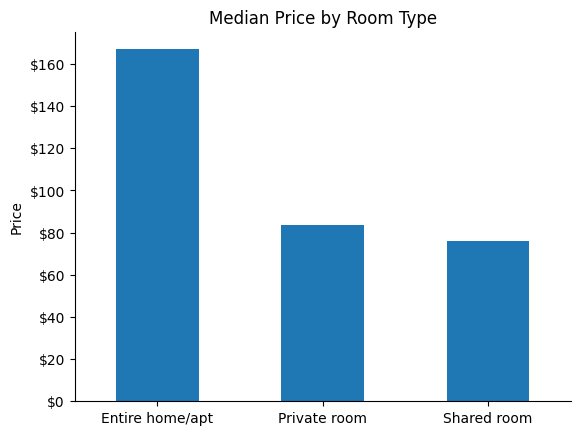

In [37]:
ax = room_type_price['median_price'].plot(kind="bar")

ax.set_title("Median Price by Room Type")
ax.set_ylabel("Price")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(price_formatter)

# Clean look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

plt.xticks(rotation=0)
plt.show()

Entire home or apartment listings have the highest typical prices, while private rooms are much cheaper. Shared rooms should be interpreted cautiously because there is only one listing in this category after filtering.

### Price by Number of Bedrooms

In [38]:
bedroom_price = (
    analysis_df.groupby("bedrooms")["price"]
    .agg(
        average_price="mean",
        median_price="median",
        standard_deviation="std",
        count="count",
    )
    .reset_index()
    .sort_values("bedrooms")
    .round(2)
)

bedroom_price

,bedrooms,average_price,median_price,standard_deviation,count
0,0.0,127.25,117.0,42.77,336
1,1.0,134.50,119.0,92.60,1828
2,2.0,192.52,176.0,80.05,1258
3,3.0,250.49,226.0,109.66,647
4,4.0,338.48,301.0,168.79,234
5,5.0,455.64,378.0,262.98,72
6,6.0,488.29,459.5,195.83,42
7,7.0,641.50,561.5,324.83,12
8,8.0,678.38,633.5,202.63,8
9,9.0,492.00,492.0,NaN,1


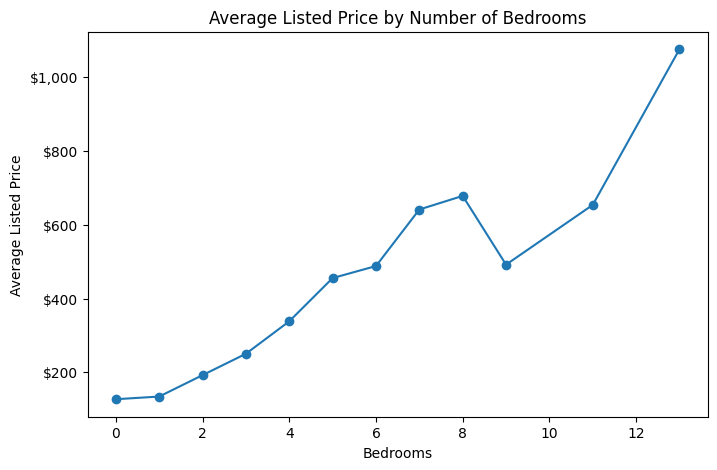

In [39]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(bedroom_price["bedrooms"], bedroom_price["average_price"], marker="o")
ax.set_title("Average Listed Price by Number of Bedrooms")
ax.set_xlabel("Bedrooms")
ax.set_ylabel("Average Listed Price")
ax.yaxis.set_major_formatter(price_formatter)
plt.show()

Price generally increases with the number of bedrooms. The pattern becomes noisier for very large listings because the sample sizes are quite small at the upper end of the bedroom distribution.

There is only one listing each with 9 and 11 bedrooms.

### Price vs Accommodation Capacity

In [40]:
accom_price = (
    analysis_df.groupby("accommodates")["price"]
    .agg(
        average_price="mean",
        median_price="median",
        standard_deviation="std",
        count="count",
    )
    .reset_index()
    .sort_values("accommodates")
    .round(2)
)

accom_price

,accommodates,average_price,median_price,standard_deviation,count
0,2,124.26,108.0,95.57,1367
1,3,131.94,122.5,43.24,336
2,4,173.45,156.0,81.98,1131
3,5,185.37,168.0,84.37,265
4,6,230.95,209.0,103.07,703
5,7,228.50,214.5,69.00,124
6,8,290.17,255.0,135.55,271
7,9,311.40,261.0,150.51,42
8,10,360.42,325.5,190.74,100
9,11,363.69,355.5,147.34,16


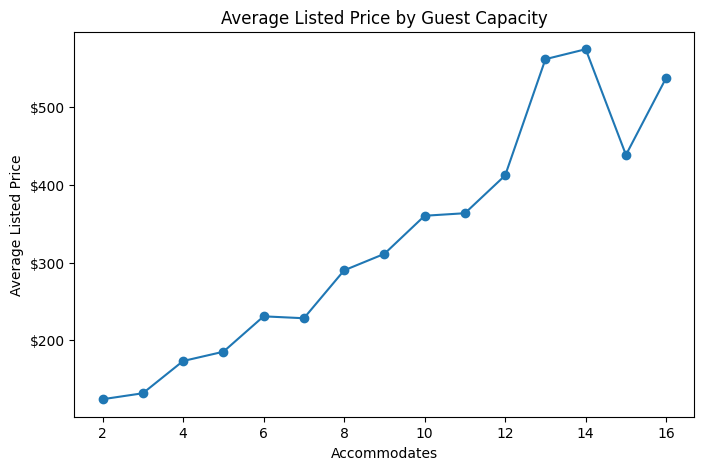

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(accom_price["accommodates"], accom_price["average_price"], marker="o")
ax.set_title("Average Listed Price by Guest Capacity")
ax.set_xlabel("Accommodates")
ax.set_ylabel("Average Listed Price")
ax.yaxis.set_major_formatter(price_formatter)
plt.show()

Listings that accommodate more guests tend to have higher prices, which suggests that size and capacity are important drivers of listing value.

# Overall Conclusion
The notebook shows that listing prices vary across both neighborhood groups and property characteristics. Neighborhood differences are meaningful, but much of the observed variation appears to be tied to composition, especially room type and listing size. Across the full sample, larger listings and entire homes consistently command higher prices.
